# Weryfikacja Jakości Danych (EDA) - Projekt IUM Zadanie 7
## Cel: Potwierdzenie gotowości nowej paczki danych do budowy modelu predykcyjnego (Etap 2).

W tej iteracji analizy badamy kompletność danych po naprawie identyfikatorów, analizujemy rozkład długości pobytów oraz weryfikujemy potencjał predykcyjny cech (korelacje z celem).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df_listings = pd.read_csv('listings.csv')
df_sessions = pd.read_csv('sessions.csv')

df_listings['price_num'] = df_listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df_listings['price_num'] = pd.to_numeric(df_listings['price_num'], errors='coerce')

bookings = df_sessions[df_sessions['action'] == 'book_listing'].copy()
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'], errors='coerce')
bookings['booking_duration'] = pd.to_datetime(bookings['booking_duration'], errors='coerce')
bookings['stay_length_days'] = (bookings['booking_duration'] - bookings['booking_date']).dt.days

print("Liczba wszystkich zdarzeń 'book_listing':", len(bookings))

Liczba wszystkich zdarzeń 'book_listing': 228021


## 1. Weryfikacja Kompletności Danych (Integracja tabel)
Sprawdzamy, czy naprawione klucze główne i obce pozwalają na poprawne złączenie historii sesji z cechami lokali bez utraty wierszy.

In [60]:
total_bookings = len(bookings)

valid_stay_length = bookings.dropna(subset=['stay_length_days']).copy()
valid_listing_id = valid_stay_length.dropna(subset=['listing_id']).copy()
merged_data = valid_listing_id.merge(df_listings, left_on='listing_id', right_on='id', how='inner')

print(f"Początkowa liczba rezerwacji: {total_bookings}")
print(f"Wielkość zbioru połączonego (JOIN): {len(merged_data)}")
print(f"Retencja danych: {len(merged_data)/total_bookings*100:.1f}%")
print("\nWNIOSEK BIZNESOWY: Zbiór jest kompletny. Problemy z brakującymi kluczami zostały wyeliminowane, co daje nam bardzo duży, stabilny zbiór treningowy (ponad 228 tys. rekordów).")

Początkowa liczba rezerwacji: 228021
Wielkość zbioru połączonego (JOIN): 228021
Retencja danych: 100.0%

WNIOSEK BIZNESOWY: Zbiór jest kompletny. Problemy z brakującymi kluczami zostały wyeliminowane, co daje nam bardzo duży, stabilny zbiór treningowy (ponad 228 tys. rekordów).


## 2. Profilowanie Długości Pobytu (Rozkład Zmiennej Celu)
Definiujemy środowisko dla problemu biznesowego. Badamy rozkład zmiennej `stay_length_days`.

In [61]:
print("Statystyki opisowe dla wyliczonej długości pobytu (stay_length_days):")
display(merged_data['stay_length_days'].describe())

print(f"\nRezerwacje >= 7 dni: {(merged_data['stay_length_days'] >= 7).sum()} ({(merged_data['stay_length_days'] >= 7).mean()*100:.1f}%)")

print("\nWNIOSEK BIZNESOWY: Zakres obserwacji wynosi od 1 do 14 dni. Zbiór jest dobrze zbalansowany. Na potrzeby projektu definiujemy 'dłuższy nocleg' jako pobyt trwający od 7 do 14 dni. Taka klasa stanowi niemal 33% całego zbioru, co jest idealną proporcją do klasyfikacji.")

Statystyki opisowe dla wyliczonej długości pobytu (stay_length_days):


count    228021.000000
mean          5.263515
std           2.733080
min           1.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          14.000000
Name: stay_length_days, dtype: float64


Rezerwacje >= 7 dni: 74772 (32.8%)

WNIOSEK BIZNESOWY: Zakres obserwacji wynosi od 1 do 14 dni. Zbiór jest dobrze zbalansowany. Na potrzeby projektu definiujemy 'dłuższy nocleg' jako pobyt trwający od 7 do 14 dni. Taka klasa stanowi niemal 33% całego zbioru, co jest idealną proporcją do klasyfikacji.


## 3. Potencjał Predykcyjny (Analiza Korelacji)
Sprawdzamy, czy dostępne cechy lokali niosą w sobie tzw. 'sygnał' – czy mają matematyczny związek z decyzją o długości pobytu.

In [62]:
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_num', 'number_of_reviews', 'review_scores_rating']

print("Korelacja cech lokalu z długością pobytu (Pearson):")
correlations = merged_data[['stay_length_days'] + numeric_features].corr()['stay_length_days'].drop('stay_length_days')
print(correlations.sort_values(ascending=False))

print("\nWNIOSEK BIZNESOWY:")
print("Obecne dane mają BARDZO DOBRY potencjał predykcyjny. Widzimy wyraźne zależności:")
print("1. Silna korelacja dodatnia (0.34) z ocenami lokalu (review_scores_rating) - klienci długoterminowi wybierają sprawdzone miejsca o wysokim standardzie.")
print("2. Wyraźna korelacja ujemna (-0.24) z wielkością mieszkania (accommodates/beds) - długie pobyty częściej rezerwują mniejsze grupy/singli (np. podróże służbowe).")
print("Dzięki tym zależnościom, zbudowany model z powodzeniem znajdzie kluczowe kryteria i będzie wysoce użyteczny dla konsultantów Nocarza.")

Korelacja cech lokalu z długością pobytu (Pearson):
review_scores_rating    0.342279
bathrooms              -0.007630
price_num              -0.109876
bedrooms               -0.120800
number_of_reviews      -0.149728
beds                   -0.200059
accommodates           -0.246115
Name: stay_length_days, dtype: float64

WNIOSEK BIZNESOWY:
Obecne dane mają BARDZO DOBRY potencjał predykcyjny. Widzimy wyraźne zależności:
1. Silna korelacja dodatnia (0.34) z ocenami lokalu (review_scores_rating) - klienci długoterminowi wybierają sprawdzone miejsca o wysokim standardzie.
2. Wyraźna korelacja ujemna (-0.24) z wielkością mieszkania (accommodates/beds) - długie pobyty częściej rezerwują mniejsze grupy/singli (np. podróże służbowe).
Dzięki tym zależnościom, zbudowany model z powodzeniem znajdzie kluczowe kryteria i będzie wysoce użyteczny dla konsultantów Nocarza.


## 4. Analiza Rozkładów (Wizualizacja Zmiennej Celu i Atrybutów)
Weryfikujemy graficznie rozkład zmiennej celu oraz kluczowych atrybutów branych pod uwagę w modelowaniu, dzieląc je na zmienne dyskretne (wykresy słupkowe) i ciągłe (histogramy).

--- ROZKŁAD ZMIENNEJ CELU ---


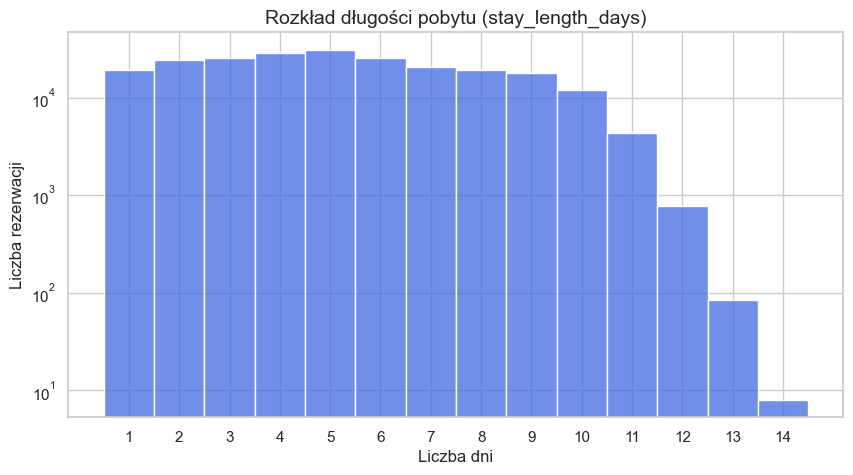


--- ROZKŁADY ATRYBUTÓW CIĄGŁYCH / QUASI-CIĄGŁYCH ---
count    199306.000000
mean        131.739832
std         290.827795
min           5.000000
25%          72.000000
50%         109.000000
75%         161.000000
max       50000.000000
Name: price_num, dtype: float64
count    228021.000000
mean          4.772684
std           0.177023
min           1.000000
25%           4.680000
50%           4.810000
75%           4.900000
max           5.000000
Name: review_scores_rating, dtype: float64
count    228021.000000
mean        257.358015
std         263.010352
min           1.000000
25%          80.000000
50%         189.000000
75%         343.000000
max        1628.000000
Name: number_of_reviews, dtype: float64


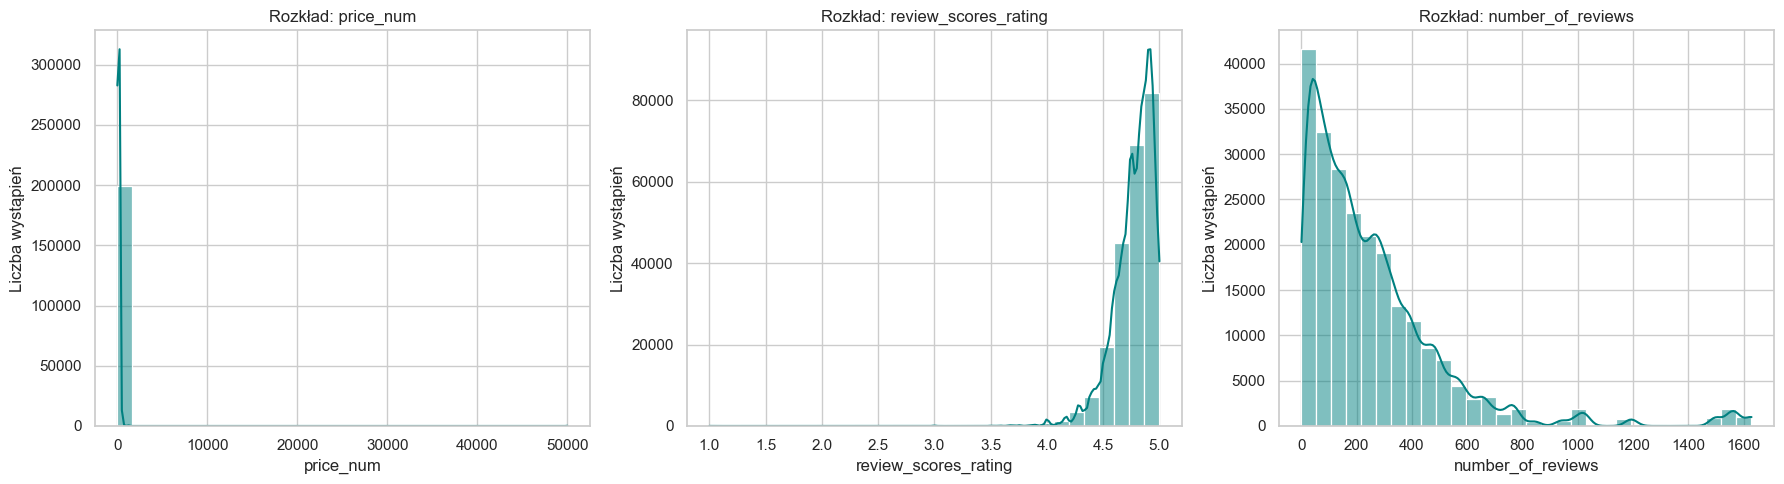


--- ROZKŁADY ATRYBUTÓW DYSKRETNYCH ---
count    228021.000000
mean          3.530745
std           2.241138
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64
count    199671.000000
mean          2.299513
std           1.733083
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: beds, dtype: float64
count    216200.000000
mean          1.341665
std           0.875472
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          14.000000
Name: bedrooms, dtype: float64


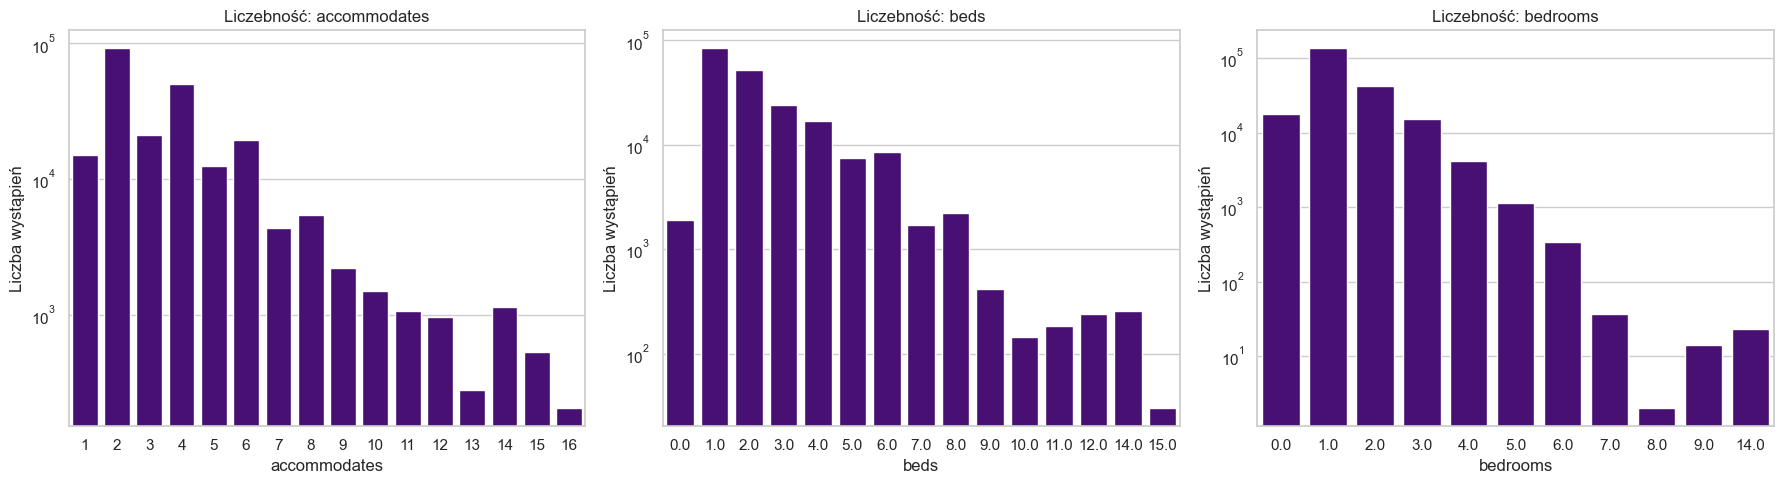

In [63]:
sns.set_theme(style="whitegrid")

print("--- ROZKŁAD ZMIENNEJ CELU ---")
plt.figure(figsize=(10, 5))
sns.histplot(merged_data['stay_length_days'], bins=14, discrete=True, color='royalblue')
plt.title('Rozkład długości pobytu (stay_length_days)', fontsize=14)
plt.xlabel('Liczba dni', fontsize=12)
plt.ylabel('Liczba rezerwacji', fontsize=12)
plt.yscale('log')
plt.xticks(range(1, 15))
plt.show()

print("\n--- ROZKŁADY ATRYBUTÓW CIĄGŁYCH / QUASI-CIĄGŁYCH ---")
continuous_features = ['price_num', 'review_scores_rating', 'number_of_reviews']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(continuous_features):
    sns.histplot(merged_data[feature].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Rozkład: {feature}', fontsize=12)
    axes[i].set_ylabel('Liczba wystąpień')
    axes[i].set_xlabel(feature)
    print(merged_data[feature].describe())

plt.tight_layout()
plt.show()

print("\n--- ROZKŁADY ATRYBUTÓW DYSKRETNYCH ---")
discrete_features = ['accommodates', 'beds', 'bedrooms']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(discrete_features):
    sns.countplot(data=merged_data, x=feature, ax=axes[i], color='indigo')
    axes[i].set_title(f'Liczebność: {feature}', fontsize=12)
    axes[i].set_ylabel('Liczba wystąpień')
    axes[i].set_xlabel(feature)
    axes[i].set_yscale('log')
    print(merged_data[feature].describe())

plt.tight_layout()
plt.show()